# Toy diffusion model generating data from a complex 2-d distribution

## General imports

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns

## Load training data

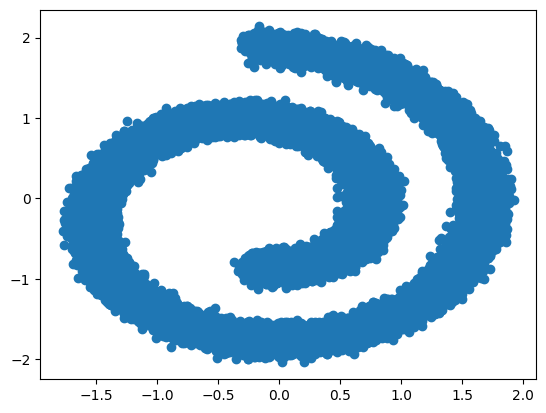

In [2]:
from sklearn.datasets import make_swiss_roll

x, _ = make_swiss_roll(n_samples=100000, noise=0.5)
# Make two-dimensional to easen visualization
x = x[:, [0, 2]]

x = (x - x.mean()) / x.std()

plt.scatter(x[:, 0], x[:, 1])

## Prepare data for learning

In [3]:
import torch

X = torch.tensor(x, dtype=torch.float32)

## Diffusion model hyperparameters

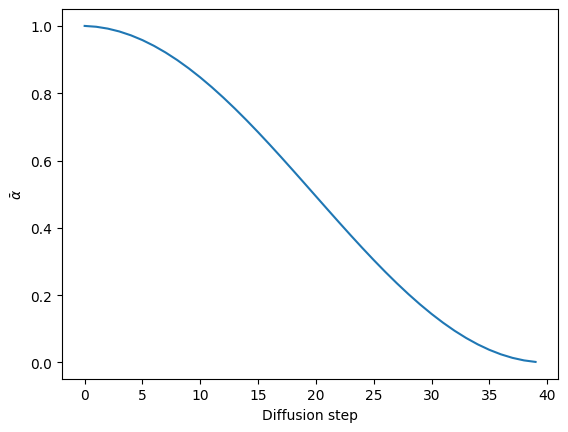

In [4]:
num_steps = 40  # Number of steps in the diffusion process

# Set noising variances betas as in Nichol and Dariwal paper (https://arxiv.org/pdf/2102.09672.pdf)
s = 0.008
timesteps = torch.tensor(range(0, num_steps), dtype=torch.float32)
schedule = torch.cos((timesteps / num_steps + s) / (1 + s) * torch.pi / 2)**2

baralphas = schedule / schedule[0]
betas = 1 - baralphas / torch.concatenate([baralphas[0:1], baralphas[0:-1]])
alphas = 1 - betas

# Check the cumulative alphas follow the distribution recommended in the paper
sns.lineplot(baralphas)
plt.xlabel("Diffusion step")
plt.ylabel(r"$\bar{\alpha}$")
plt.show()

Function that noises a data point following the diffusion process

In [5]:
def noise(Xbatch, t):
    eps = torch.randn(size=Xbatch.shape)
    noised = (baralphas[t] ** 0.5).repeat(1, Xbatch.shape[1]) * Xbatch + ((1 - baralphas[t]) ** 0.5).repeat(1, Xbatch.shape[1]) * eps
    return noised, eps

Test noising the training data

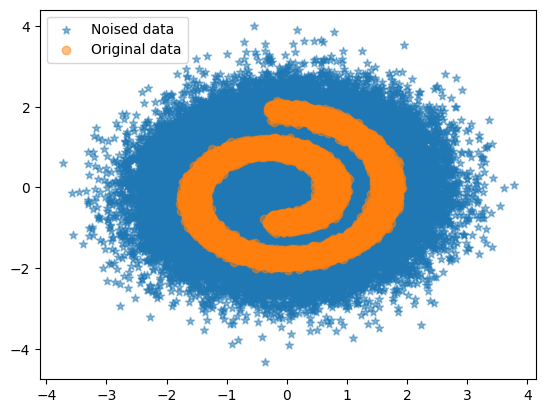

In [6]:
noiselevel = 20

noised, eps = noise(X, torch.full([len(X), 1], fill_value=noiselevel))
plt.scatter(noised[:, 0], noised[:, 1], marker="*", alpha=0.5)
plt.scatter(X[:, 0], X[:, 1], alpha=0.5)
plt.legend(["Noised data", "Original data"])
plt.show()

Since we know the noise we just added, we can recover the original data as follows:

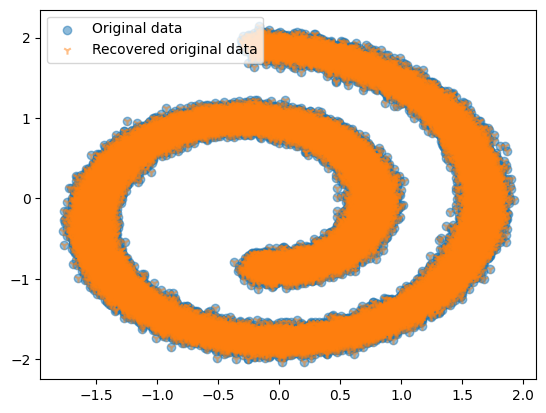

In [7]:
denoised = 1 / torch.sqrt(baralphas[noiselevel]) * (noised - torch.sqrt(1 - baralphas[noiselevel]) * eps)
plt.scatter(X[:, 0], X[:, 1], alpha=0.5)
plt.scatter(denoised[:, 0], denoised[:, 1], marker="1", alpha=0.5)
plt.legend(["Original data", "Recovered original data"])
plt.show()

We can also check numerically that the result is the same

In [8]:
X - denoised

tensor([[ 7.4506e-09,  0.0000e+00],
        [ 0.0000e+00,  0.0000e+00],
        [ 2.3842e-07, -2.9802e-08],
        ...,
        [-5.9605e-08,  0.0000e+00],
        [-2.9802e-08,  0.0000e+00],
        [ 1.4901e-08, -1.1921e-07]])

## Diffusion network

Now we define a pytorch network that will learn to predict the noise component from noised data.

In [9]:
import torch.nn as nn

class Block(nn.Module):
    def __init__(self, nunits):
        super().__init__()
        self.linear = nn.Linear(nunits, nunits)
        
    def forward(self, x: torch.Tensor):
        x = self.linear(x)
        x = nn.functional.relu(x)
        return x
        
    
class Toy_Model(nn.Module):
    def __init__(self, nfeatures: int, nblocks: int = 2, nunits: int = 64):
        super().__init__()
        
        self.inblock = nn.Linear(nfeatures+1, nunits)
        self.midblocks = nn.ModuleList([Block(nunits) for _ in range(nblocks)])
        self.outblock = nn.Linear(nunits, nfeatures)

    def forward(self, x: torch.Tensor, t: torch.Tensor) -> torch.Tensor:
        val = torch.hstack([x, t])  # Add t to inputs
        val = self.inblock(val)
        for midblock in self.midblocks:
            val = midblock(val)
        val = self.outblock(val)
        return val

Let's create a model with 4 inner blocks, which is enough for this problem.

In [10]:
model = Toy_Model(nfeatures=2, nblocks=4)

device = "cuda"
model = model.to(device)

model

Toy_Model(
  (inblock): Linear(in_features=3, out_features=64, bias=True)
  (midblocks): ModuleList(
    (0-3): 4 x Block(
      (linear): Linear(in_features=64, out_features=64, bias=True)
    )
  )
  (outblock): Linear(in_features=64, out_features=2, bias=True)
)

## Train denoising network

In [11]:
import torch.optim as optim

nepochs = 100
batch_size = 2048

loss_fn = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.LinearLR(optimizer, start_factor=1.0, end_factor=0.01, total_iters=nepochs)

for epoch in range(nepochs):
    epoch_loss = steps = 0
    for i in range(0, len(X), batch_size):
        Xbatch = X[i:i+batch_size]
        timesteps = torch.randint(0, num_steps, size=[len(Xbatch), 1])
        noised, eps = noise(Xbatch, timesteps)
        predicted_noise = model(noised.to(device), timesteps.to(device))
        loss = loss_fn(predicted_noise, eps.to(device))
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_loss += loss
        steps += 1
    print(f"Epoch {epoch} loss = {epoch_loss / steps}")

Epoch 0 loss = 0.7822179794311523
Epoch 1 loss = 0.533292829990387
Epoch 2 loss = 0.5167884826660156
Epoch 3 loss = 0.51012122631073
Epoch 4 loss = 0.4917207658290863
Epoch 5 loss = 0.4880177974700928
Epoch 6 loss = 0.4800078570842743
Epoch 7 loss = 0.47989851236343384
Epoch 8 loss = 0.47465547919273376
Epoch 9 loss = 0.47634702920913696
Epoch 10 loss = 0.4687061309814453
Epoch 11 loss = 0.46623140573501587
Epoch 12 loss = 0.4646073579788208
Epoch 13 loss = 0.4678327143192291
Epoch 14 loss = 0.466407835483551
Epoch 15 loss = 0.4659923017024994
Epoch 16 loss = 0.4670103192329407
Epoch 17 loss = 0.45927098393440247
Epoch 18 loss = 0.4657372832298279
Epoch 19 loss = 0.458905965089798
Epoch 20 loss = 0.45941483974456787
Epoch 21 loss = 0.45767566561698914
Epoch 22 loss = 0.45545125007629395
Epoch 23 loss = 0.4539451599121094
Epoch 24 loss = 0.45894384384155273
Epoch 25 loss = 0.45401400327682495
Epoch 26 loss = 0.45298683643341064
Epoch 27 loss = 0.4518751800060272
Epoch 28 loss = 0.449172

## Sampling algorithm

We will use the classic DDPM sampler, defined as follows

In [12]:
def sample(model, nsamples, nfeatures):
    """Sampler following the Denoising Diffusion Probabilistic Models method by Ho et al (Algorithm 2)"""
    with torch.no_grad():
        x = torch.randn(size=(nsamples, nfeatures)).to(device)
        xt = [x]
        for t in range(num_steps-1, 0, -1):
            predicted_noise = model(x, torch.full([nsamples, 1], t).to(device))
            # See DDPM paper between equations 11 and 12
            x = 1 / (alphas[t] ** 0.5) * (x - (1 - alphas[t]) / ((1-baralphas[t]) ** 0.5) * predicted_noise)
            if t > 1:
                # See DDPM paper section 3.2.
                # Choosing the variance through beta_t is optimal for x_0 a normal distribution
                variance = betas[t]
                std = variance ** (0.5)
                x += std * torch.randn(size=(nsamples, nfeatures)).to(device)
            xt += [x]
        return x, xt

## Test generation

Let's generate 10K samples of the learned distribution using the diffusion model we just created

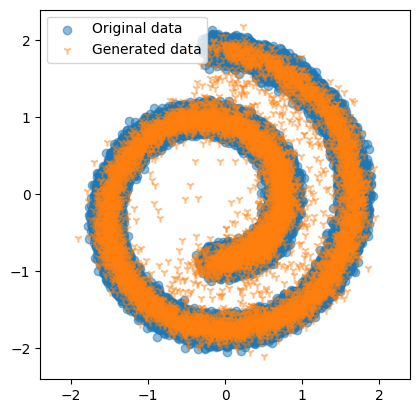

In [13]:
Xgen, Xgen_hist = sample(model, 10000, 2)
Xgen = Xgen.cpu()
plt.scatter(X[:, 0], X[:, 1], alpha=0.5)
plt.scatter(Xgen[:, 0], Xgen[:, 1], marker="1", alpha=0.5)
plt.legend(["Original data", "Generated data"])
plt.xlim(-2.4, 2.4)
plt.ylim(-2.4, 2.4)
plt.xticks([-2, -1, 0, 1, 2])
plt.yticks([-2, -1, 0, 1, 2])
plt.gca().set_aspect('equal', adjustable='box')
plt.show()